In [101]:
library(igraph)
source("Functions.R") #include some helpers

# Lesson 2 

Network structure. In this notebook we will cover how to study the structure of networks at different biological scales:
- Local scale (species)
- Global scale (community)
- Meso-scale (groups)

Apart from the functions included in *igraph*, we will use the package *bipartite* to work with mutualistic networks, as it includes many fucntions that will make our live easier, as long as we understand what they do.

## 2A Local scale (species)

### Paths 

A *path* in a network is a sequence of edges connecting two nodes. Let's start with a very simple, undirected network.

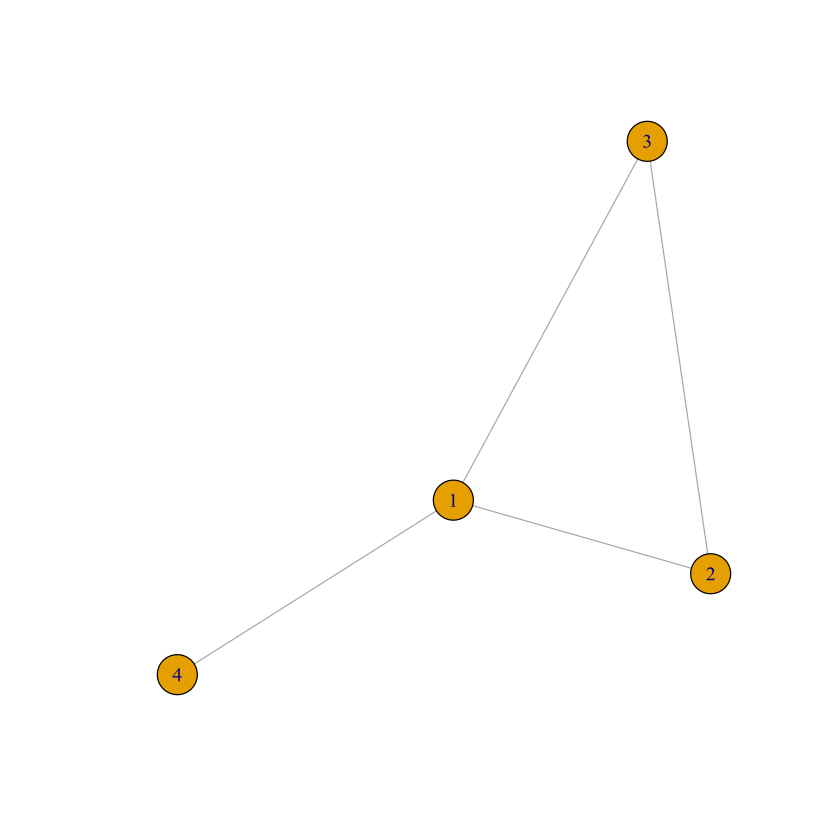

In [3]:
# Create empty undirected graph
G <- make_empty_graph(directed = FALSE)
# Add nodes
G <- add_vertices(G, 4, name = c("1","2","3","4"))
# Add edges
G <- add_edges(G, c("1","2",
                     "2","3",
                     "1","3",
                     "1","4"))

# Plot
plot(G, vertex.label = V(G)$name)

 this simple example, we can easily see that there is indeed at least one path that connects nodes 3 and 4. There can be more than one path between two nodes. Again considering nodes 3 and 4, there are two such "simple" paths that we can retrieve with `all_simple_paths(g,start,end)`

In [4]:
all_simple_paths(G, 3, 4)

[[1]]
+ 3/4 vertices, named, from 1fbb407:
[1] 3 1 4

[[2]]
+ 4/4 vertices, named, from 1fbb407:
[1] 3 2 1 4


We are often most interested in **shortest paths**. In an unweighted network, the shortest path is the one with the fewest edges. 
We can see that of the two simple paths between nodes 3 and 4, one is shorter than the other. 
We can get this shortest path with a single igraph function `all_shortest_path(G, start node, end node)$vpath[[1]]`

In [14]:
all_shortest_paths(G,3,4)$vpath[[1]] #vpath indicates we are only intersted in the node paths, i.e. going from one node to another

+ 3/4 vertices, named, from 1fbb407:
[1] 3 1 4

OR if you want to retrieve the names of the nodes

In [18]:
all_shortest_paths(G,3,4)$vpath[[1]]$name

[1] "3" "1" "4"

If you only care about the path length, there's a function for that too: `nx.shortest_path_length(G, start node, end node)`

In [16]:
as.numeric(igraph::distances(G, 3, 4))

[1] 2

> Note that a path length is defined here by the number of *edges* in the path, not the number of nodes, which implies that for nodes $u$ and $v$.
>
>    `as.numeric(igraph::distances(G, 3, 4)) == length(all_shortest_paths(G,3,4)$vpath[[1]]$name) - 1`
   

You can also obtain the average shortest path length between any pair of nodes in the network with `igraph::mean_distance(G)`, and the maximum shortest path length (or network diameter) with `igraph::diameter(G)`

In [20]:
igraph::mean_distance(G)

[1] 1.333333

In [21]:
igraph::diameter(G)

[1] 2

Let's extend these ideas about paths to directed graphs.
#### Directed paths

We know that in a directed graph, an edge from an arbitrary node $u$ to an arbitrary node $v$ does not imply that an edge exists from $v$ to $u$. Since paths must follow edge direction in directed graphs, the same asymmetry applies for paths. Observe that this graph has a path from 1 to 4, but not in the reverse direction.

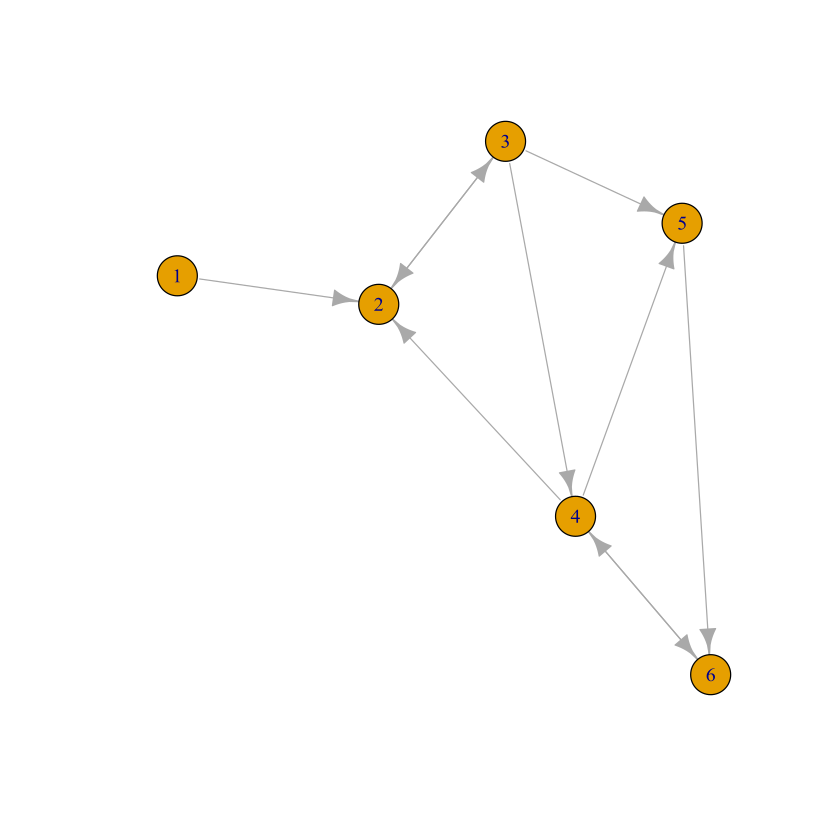

In [29]:
edges <- c(
  1,2,
  2,3,
  3,2,  3,4,  3,5,
  4,2,  4,5,  4,6,
  5,6,
  6,4
)
D <- graph(edges, directed = TRUE)
plot(D)

Can I go from node 1 to 4?  And form node 4 to 1?

In [41]:
as.numeric(igraph::distances(D, 1, 4,mode="out")) #from 1 to 4
as.numeric(igraph::distances(D, 4, 1,mode="out")) #from 4 to 1

[1] 3

[1] Inf

For shortest path we also have to take it into account
> Note: Since there is no edge from 5 to 3, the shortest path from 5 to 2 cannot simply backtrack the shortest path from 2 to 5 -- it has to go a longer route through nodes 6 and 4.

In [43]:
shortest_paths(D, 2, 5, mode = "out")$vpath[[1]]
shortest_paths(D, 5, 2, mode = "out")$vpath[[1]]

+ 3/6 vertices, from 2aae7f0:
[1] 2 3 5

+ 4/6 vertices, from 2aae7f0:
[1] 5 6 4 2

<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>
<h4> Exercise 7</h4>
Imagine that after an accident, the 'Suspension-feeding molluscs' have been contaminated with lead. Taking into cosideration the structure of the trophic interactions in the St Marks estudary, aswer the following questions:
    
- 1 Should we be worried about the well fare of the 'Tonguefish'? 
- 2 and what about the 'Fish and crustacean-eating birds'?
- 3 Should we expect more accumulation of lead in 'Herbivorous ducks' or in 'Fish and crustacean-eating birds', according to their diets? (hint: only consider length of trophic chain)
    
![title](./images/figure10.jpg)
</div>

In [102]:
# your code here . Remember we have loaded the network before, look how to do it
FW_filename<- "./Data/FW_st_marks.csv"


In [104]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex7.R")


```r
 #load the network
FW_Ilist <- read.csv(FW_filename)
FW <- graph_from_data_frame(FW_Ilist,directed = TRUE)

sp0='Suspension-feeding molluscs'
sp1='Tonguefish'
sp2='Fish and crustacean-eating birds'
sp3='Herbivorous ducks' 

#1) Do Tonguefish eat molluscs?
sp0_sp1=as.numeric(igraph::distances(FW,sp0,sp1,mode="out"))
cat(sprintf("1. It is %s that %s depends on %s\n",  is.finite(sp0_sp1), sp1, sp0
))

#2) and the Fish and crustacean eating birds?
sp0_sp2=as.numeric(igraph::distances(FW,sp0,sp2),mode="out")
cat(sprintf("2. It is %s that %s depends on %s\n",  is.finite(sp0_sp2), sp2, sp0
))

#3) Should ducka or birds accumulate more lead?
L2=igraph::distances(FW,sp0,sp2,mode="out",weights = NA)
L3=igraph::distances(FW,sp0,sp3,mode="out",weights=NA)

if (L2 < L3) {
  cat(sprintf("3. %s are in more danger since they are only %s steps away and %s are %s steps away\n",sp2, L2, sp3, L3
  ))
} else {
  cat(sprintf("3. %s are in more danger since they are only %s steps away and %s are %s step

[1] 2.524876

## Centrality metrics I

Let's take a look at these two networks, what is the bigger difference?

![title](./images/figure7.png)

The most basic structural properties of a network are the number of nodes (**N**) and the number of links (**L**). However, how these links are distributed among the nodes (**$K_i$**) has deep implications for other network properties (it is not the same to have all nodes with similar degree, or having a very heterogeneous dostribution). 

The degree distribution will play a very important role determining other structural metrics in the networks.
We can see the **degree distribution** of a network by doing a histogram of the degree series. This will tell us how many nodes with a given number of neighbours are in the network.

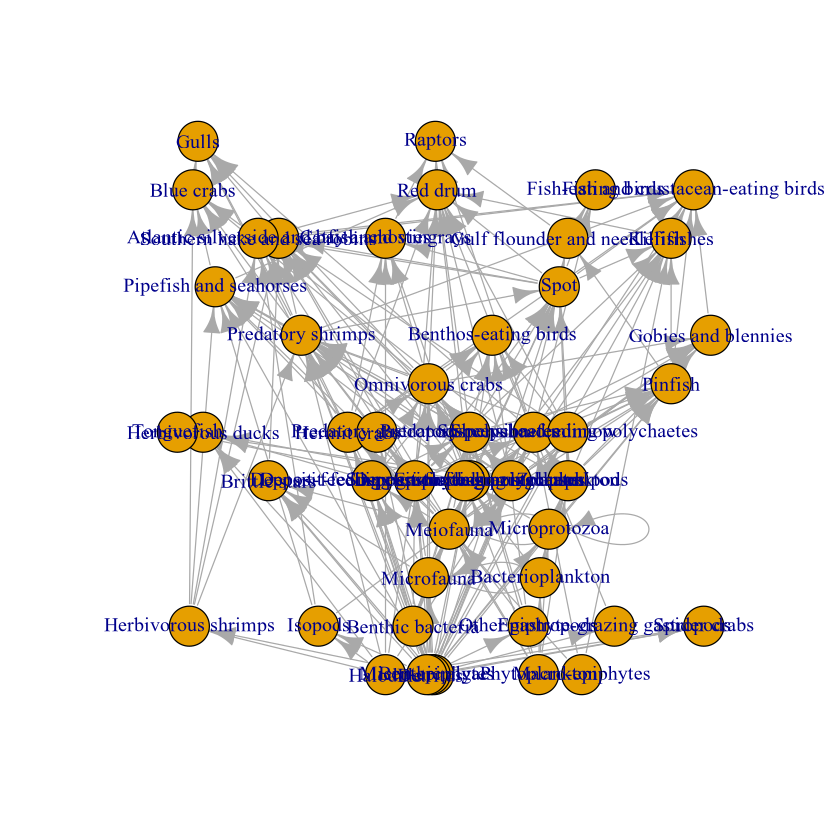

In [ ]:
plot_as_flux(FW)

## 2B Global scale (community)

## 2C Meso-Scale